In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.3 MB/s eta 0:00:00


In [2]:
# CELL 1 - Active learning COCO -> YOLO train/val hazırlığı

import json
import os
import shutil
from pathlib import Path
from collections import defaultdict

BASE = Path("/kaggle/working/drone_dataset")
ACTIVE_ROOT = Path("/kaggle/input/datasets/zgeiklar/active-learning-round1")  # gerekirse Kaggle path ile değiştir
VAL_VIDEO_PREFIX = "DJI_0574"  # validation'a ayrılacak video prefix'i

# Temiz çalışma klasörü
shutil.rmtree(BASE, ignore_errors=True)
for split in ["train", "val"]:
    (BASE / "images" / split).mkdir(parents=True, exist_ok=True)
    (BASE / "labels" / split).mkdir(parents=True, exist_ok=True)

# COCO annotation dosyasını bul
ann_path = ACTIVE_ROOT / "annotations" / "instances_default.json"
if not ann_path.exists():
    matches = list(ACTIVE_ROOT.rglob("instances_default.json"))
    if not matches:
        raise FileNotFoundError("instances_default.json bulunamadı")
    ann_path = matches[0]

with open(ann_path, "r") as f:
    coco = json.load(f)

# Görsellerin olduğu klasörü bul
image_files = {}
for ext in ("*.jpg", "*.jpeg", "*.png"):
    for p in ACTIVE_ROOT.rglob(ext):
        image_files[p.name] = p

print("Annotation:", ann_path)
print("Bulunan görsel:", len(image_files))

# Annotation'ları image_id'ye göre grupla
anns_by_image = defaultdict(list)
for ann in coco["annotations"]:
    if ann.get("iscrowd", 0):
        continue
    anns_by_image[ann["image_id"]].append(ann)

train_count = val_count = 0
train_boxes = val_boxes = 0

for img in coco["images"]:
    file_name = Path(img["file_name"]).name
    stem = Path(file_name).stem

    split = "val" if stem.startswith(VAL_VIDEO_PREFIX) else "train"

    src_img = image_files.get(file_name)
    if src_img is None:
        raise FileNotFoundError(f"Görsel bulunamadı: {file_name}")

    dst_img = BASE / "images" / split / file_name
    shutil.copy2(src_img, dst_img)

    label_path = BASE / "labels" / split / f"{stem}.txt"
    lines = []

    img_w = img["width"]
    img_h = img["height"]

    for ann in anns_by_image.get(img["id"], []):
        x, y, w, h = ann["bbox"]
        if w <= 0 or h <= 0:
            continue

        # COCO [x, y, w, h] -> YOLO [class, cx, cy, w, h] normalized
        cx = (x + w / 2) / img_w
        cy = (y + h / 2) / img_h
        nw = w / img_w
        nh = h / img_h

        cx = min(max(cx, 0.0), 1.0)
        cy = min(max(cy, 0.0), 1.0)
        nw = min(max(nw, 0.0), 1.0)
        nh = min(max(nh, 0.0), 1.0)

        # Tek hedef sınıfımız person. COCO'da category_id=1 olsa bile YOLO label id=0.
        lines.append(f"0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

    # Boş dosya da yazılır; YOLO bunu negatif örnek olarak okuyabilir.
    label_path.write_text("\n".join(lines) + ("\n" if lines else ""))

    if split == "train":
        train_count += 1
        train_boxes += len(lines)
    else:
        val_count += 1
        val_boxes += len(lines)

print(f"Train görsel: {train_count}, train kutu: {train_boxes}")
print(f"Val görsel  : {val_count}, val kutu  : {val_boxes}")

if val_count == 0:
    raise ValueError(f"Validation boş. VAL_VIDEO_PREFIX='{VAL_VIDEO_PREFIX}' active learning datasında yok.")

Annotation: /kaggle/input/datasets/zgeiklar/active-learning-round1/annotations/instances_default.json
Bulunan görsel: 93
Train görsel: 73, train kutu: 397
Val görsel  : 20, val kutu  : 48


In [3]:
!cat /kaggle/working/drone_dataset/labels/train/Berghouse_Leopard_Jog_f000000.txt

0 0.484504 0.504597 0.023383 0.116000
0 0.523555 0.610896 0.041328 0.158181


In [4]:
import yaml, os, ultralytics
src = os.path.join(os.path.dirname(ultralytics.__file__), 'cfg/datasets/coco.yaml')
coco_names = yaml.safe_load(open(src))['names']

cfg = {
    'path': '/kaggle/working/drone_dataset',
    'train': 'images/train',
    'val': 'images/val',
    'names': coco_names,   # 80 sınıf, 0 = person
}
yaml.safe_dump(cfg, open('/kaggle/working/dataset80.yaml', 'w'), sort_keys=False)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


--- TRAIN SETİ KONTROLÜ ---


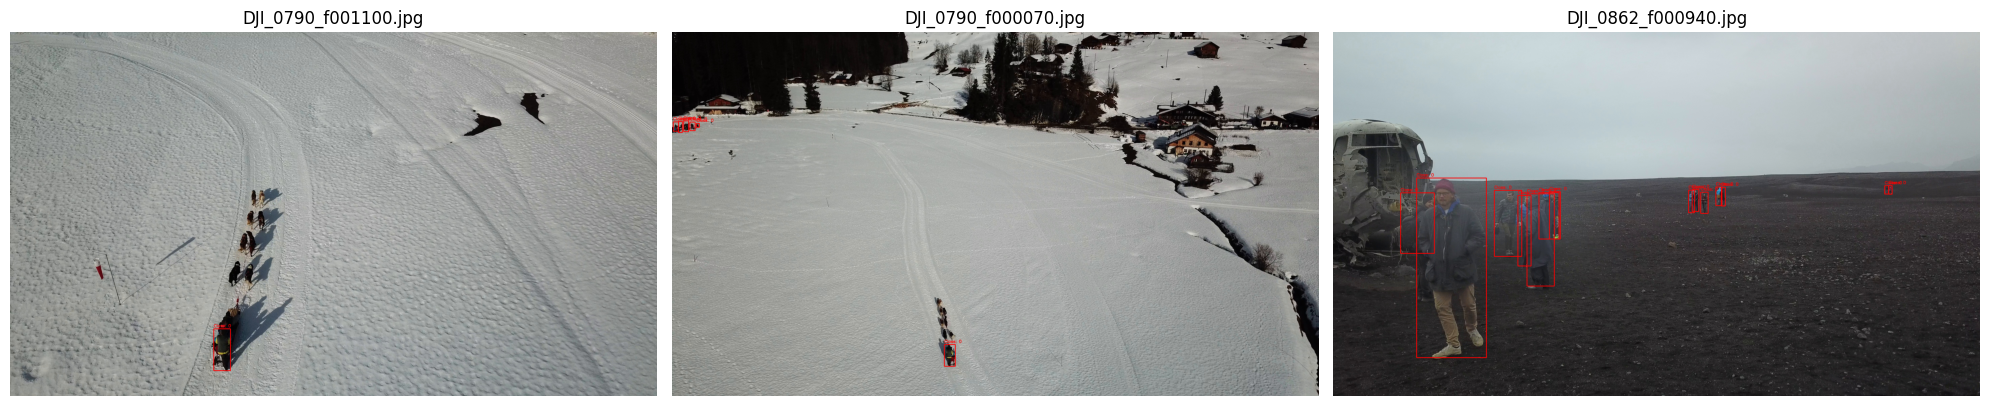

--- VALIDATION SETİ KONTROLÜ ---


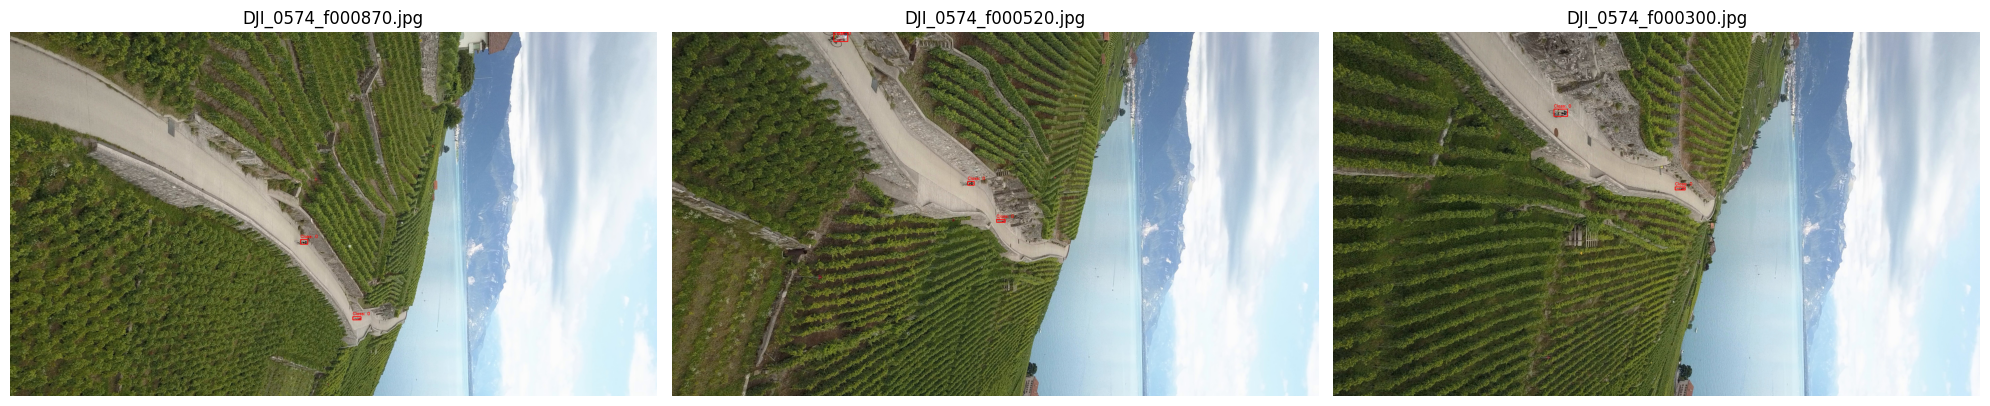

In [5]:
import cv2
import os
import random
import matplotlib.pyplot as plt

def visualize_yolo_bboxes(image_dir, label_dir, num_samples=3):
    # Klasördeki resimlerin listesini al
    images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    if not images:
        print(f"Resim bulunamadı: {image_dir}")
        return

    # Rastgele resimler seç
    selected_images = random.sample(images, min(num_samples, len(images)))
    
    plt.figure(figsize=(20, 10))
    
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(image_dir, img_name)
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(label_dir, label_name)
        
        # Resmi OpenCV ile oku ve BGR'den RGB'ye çevir (Matplotlib için)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        # Etiket dosyası varsa oku ve çiz
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, x_center, y_center, bbox_w, bbox_h = map(float, parts)
                    
                    # Normalize YOLO koordinatlarını mutlak piksel koordinatlarına çevir
                    x_center, y_center = int(x_center * w), int(y_center * h)
                    bbox_w, bbox_h = int(bbox_w * w), int(bbox_h * h)
                    
                    # cv2.rectangle için min x,y ve max x,y değerlerini hesapla
                    x_min = int(x_center - bbox_w / 2)
                    y_min = int(y_center - bbox_h / 2)
                    x_max = int(x_center + bbox_w / 2)
                    y_max = int(y_center + bbox_h / 2)
                    
                    # Bounding box'ı kırmızı renkle çiz
                    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 3)
                    # Label ID'sini ekle
                    cv2.putText(img, f'Class: {int(class_id)}', (x_min, max(15, y_min - 10)), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        
        # Görseli Matplotlib alt grafiğine (subplot) ekle
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"{img_name}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

base_dir = '/kaggle/working/drone_dataset'

print("--- TRAIN SETİ KONTROLÜ ---")
visualize_yolo_bboxes(image_dir=f'{base_dir}/images/train', 
                      label_dir=f'{base_dir}/labels/train', 
                      num_samples=3)

print("--- VALIDATION SETİ KONTROLÜ ---")
visualize_yolo_bboxes(image_dir=f'{base_dir}/images/val', 
                      label_dir=f'{base_dir}/labels/val', 
                      num_samples=3)

In [6]:
# İlk 5 etiketin içeriğini ekrana basar
!head -n 5 /kaggle/working/drone_dataset/labels/train/*.txt | head -n 10

==> /kaggle/working/drone_dataset/labels/train/Berghouse_Leopard_Jog_f000000.txt <==
0 0.484504 0.504597 0.023383 0.116000
0 0.523555 0.610896 0.041328 0.158181

==> /kaggle/working/drone_dataset/labels/train/Berghouse_Leopard_Jog_f000070.txt <==
0 0.392770 0.517250 0.038680 0.134278
0 0.587430 0.569535 0.054266 0.155681

==> /kaggle/working/drone_dataset/labels/train/Berghouse_Leopard_Jog_f000160.txt <==
0 0.532965 0.605292 0.042414 0.158778
head: write error: Broken pipe


In [7]:
!rm -rf /kaggle/working/drone_dataset/images/train/default
!rm -rf /kaggle/working/drone_dataset/images/val/default
# stale cache'leri temizle (bunlar labels/ içinde DEĞİL, kardeş dosya)
!rm -f /kaggle/working/drone_dataset/labels/train.cache
!rm -f /kaggle/working/drone_dataset/labels/val.cache

In [8]:
!find /kaggle/working/drone_dataset/images/train -type f | wc -l
!ls /kaggle/working/drone_dataset/labels/train/*.txt | wc -l
!cat /kaggle/working/drone_dataset/labels/train/*.txt | wc -l   # toplam nesne
!cat /kaggle/working/drone_dataset/labels/val/*.txt | wc -l     # 584 çıkmalı
# bozuk (sıfır boyutlu) kutu var mı
!awk '$4<=0 || $5<=0' /kaggle/working/drone_dataset/labels/train/*.txt

73
73
397
48


In [9]:
!echo "train görsel: $(find /kaggle/working/drone_dataset/images/train -type f | wc -l)"
!echo "train nesne:  $(cat /kaggle/working/drone_dataset/labels/train/*.txt | wc -l)"
!echo "val görsel:   $(find /kaggle/working/drone_dataset/images/val -type f | wc -l)"
!echo "val nesne:    $(cat /kaggle/working/drone_dataset/labels/val/*.txt | wc -l)"

train görsel: 73
train nesne:  397
val görsel:   20
val nesne:    48


In [10]:
import glob
hs, ws = [], []
for f in glob.glob('/kaggle/working/drone_dataset/labels/val/*.txt'):
    for line in open(f):
        p = line.split()
        ws.append(float(p[3]) * 1536)
        hs.append(float(p[4]) * 1536)
import numpy as np
print('genişlik px:', np.percentile(ws, [10, 50, 90]))
print('yükseklik px:', np.percentile(hs, [10, 50, 90]))

genişlik px: [     14.877      24.608      36.206]
yükseklik px: [     12.726      21.194       43.15]


In [ ]:
from ultralytics import YOLO

# Modeli yükle
model = YOLO('yolo11x.pt')

# Eğitimi başlat
results = model.train(
    data='/kaggle/working/dataset80.yaml',
    epochs=50,
    imgsz=1536,              # 1536 yerine, batch'i büyütebilmek için
    batch=4,                 # GPU başına 4 -> BN daha stabil
    device=0, 
    save_period=5,         # tek GPU: DDP + küçük batch kombinasyonundan kurtul
    optimizer='AdamW',
    freeze=23,
    lr0=0.0001,              # auto'nun seçtiği 0.002 çok yüksekti
    warmup_epochs=5,
    cos_lr=True,
    patience=25,
    workers=4,
    amp=True,
    project='/kaggle/working/runs',
    name='yolo11x_round2',
    exist_ok=True,
)

Ultralytics 8.4.153 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset80.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=23, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1536, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11x_round2, nbs=64, nms=None, opset=None, o